In [14]:
import pandas as pd
df=pd.read_csv('Cleaned_Applicants.csv',parse_dates=["Application Date"])
df

,Applicant Name,Email,Phone,Domain Applied,University,Application Date,Status
0,Brittany Wheeler,robertosanchez@example.com,66676241386,Data Science,Qau,2026-01-24,REJECTED
1,Johnny Jackson,nicholasrodriguez@example.com,86946977271,Cyber Security,Comsats Islamabad,2026-01-17,UNDER REVIEW
2,Nicolas Taylor,xwood@example.com,52192053969,Data Science,Fast Nuces,2026-02-12,UNDER REVIEW
3,Bill Griffin,steve20@example.org,21482873562,Web Development,Nust,2026-05-24,UNDER REVIEW
4,Mrs. Lisa Clark Dds,swalter@example.com,10576013659,Data Science,Mode,2026-02-03,REJECTED
...,...,...,...,...,...,...,...
183,Andrea Brown,toddpierce@example.net,79928828688,Web Development,Fast Nuces,2026-01-28,UNDER REVIEW
184,Michael Barnes,ebrewer@example.net,36458044295,Data Science,Comsats Islamabad,2026-05-13,SELECTED
185,Jeffrey Meyers,lfarmer@example.com,46820709705,Data Science,Nust,2026-02-20,UNDER REVIEW
186,Stacy Mitchell,xwheeler@example.com,95475735013,UI/UX Design,Mode,2026-06-08,SELECTED


In [15]:
#checking dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Applicant Name    188 non-null    object        
 1   Email             188 non-null    object        
 2   Phone             188 non-null    int64         
 3   Domain Applied    188 non-null    object        
 4   University        188 non-null    object        
 5   Application Date  188 non-null    datetime64[ns]
 6   Status            188 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 10.4+ KB


Domain Applied
Data Science          44
Web Development       41
Mobile Development    39
Cyber Security        36
UI/UX Design          28
Name: count, dtype: int64


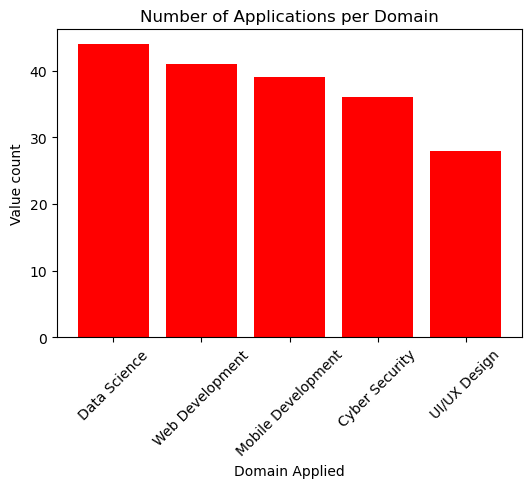

Data Science received the highest number of applications


In [34]:
#START PERFORMING EDA
import matplotlib.pyplot as plt
import seaborn as sns
#(1)Which domain received the most applications?
print(df['Domain Applied'].value_counts())
#now visualize it
dom=df['Domain Applied'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(dom.index,dom.values,color='red')
plt.title('Number of Applications per Domain')
plt.xlabel('Domain Applied')
plt.ylabel('Value count')
plt.xticks(rotation=45)
plt.show()
print('Data Science received the highest number of applications')

Application Month
2026-01    17
2026-02    32
2026-03    30
2026-04    19
2026-05    38
2026-06    36
2026-07    16
Freq: M, dtype: int64


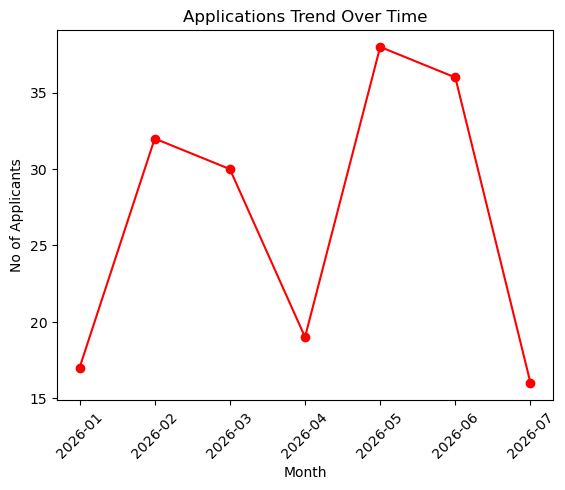

Applications reached their highest level in May 2026, remained high in June, and dropped sharply in July, indicating peak applicant interest during the middle of the recruitment period..


In [37]:
#(2)How Did Applications Trend Over Time? 
#First group by month and then find trend
# Group by month 
df['Application Month'] = df['Application Date'].dt.to_period('M') 
monthly_trend = df.groupby('Application Month').size() 
print(monthly_trend) 
#now plot line graph
plt.plot(monthly_trend.index.astype(str),#convert period dtype to string
         monthly_trend.values,#value count
         color='red',marker='o')
plt.title('Applications Trend Over Time')
plt.xlabel('Month')
plt.ylabel('No of Applicants')
plt.xticks(rotation=45)
plt.show()
print('Applications reached their highest level in May 2026, remained high in June, and dropped sharply in July, indicating peak applicant interest during the middle of the recruitment period..')

Status
UNDER REVIEW    86
REJECTED        56
SELECTED        42
MODE             4
Name: count, dtype: int64
Status              MODE  REJECTED  SELECTED  UNDER REVIEW
Domain Applied                                            
Cyber Security         1         8         8            19
Data Science           0        14        11            19
Mobile Development     3        11         9            16
UI/UX Design           0         6        10            12
Web Development        0        17         4            20
Status              MODE  REJECTED  SELECTED  UNDER REVIEW
Domain Applied                                            
Cyber Security       2.8      22.2      22.2          52.8
Data Science         0.0      31.8      25.0          43.2
Mobile Development   7.7      28.2      23.1          41.0
UI/UX Design         0.0      21.4      35.7          42.9
Web Development      0.0      41.5       9.8          48.8


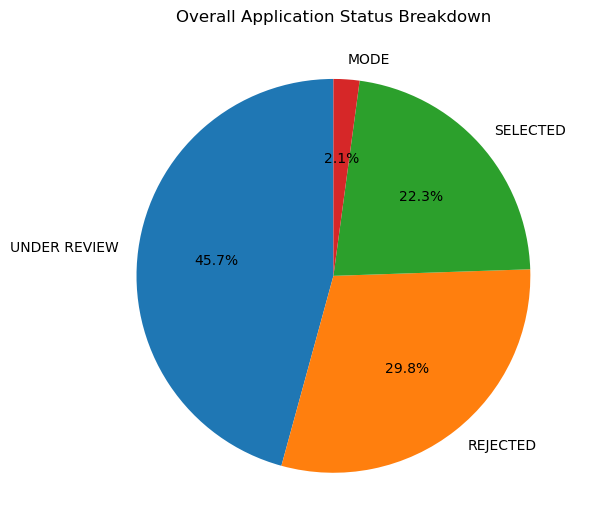

Nearly half of all applications are still under review, while selected applicants make up around 22% of the total applications.


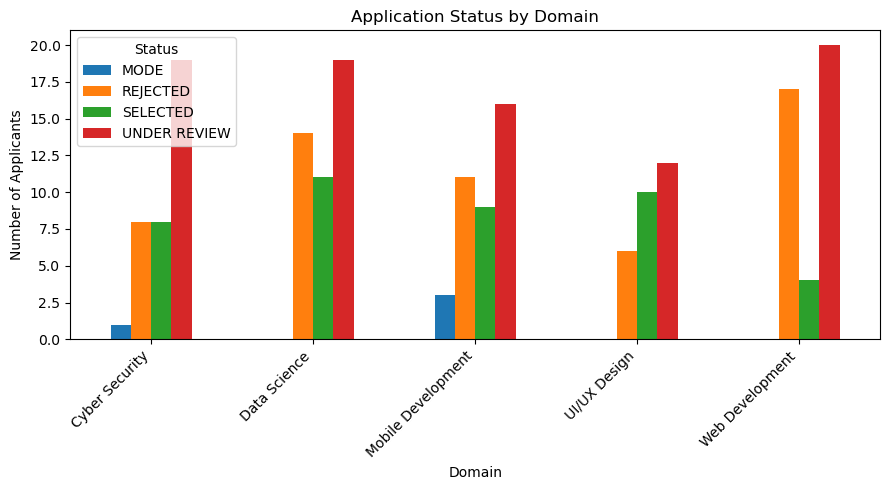

Web Development and Cyber Security have the highest number of applications under review, while Data Science has the highest number of selected applicants.


In [39]:
#What's the Acceptance Rate — Overall and Per Domain? 
status_counts = df['Status'].value_counts() 
print(status_counts) 
status_by_domain = pd.pivot_table(df,index='Domain Applied',columns='Status',values='Applicant Name',aggfunc='count',fill_value=0) 
print(status_by_domain) 
#calculate acceptance rate
status_by_domain_pct = status_by_domain.div(status_by_domain.sum(axis=1),axis=0) * 100 
print(status_by_domain_pct.round(1))
# Overall status - pie chart 
plt.figure(figsize=(6,6)) 
status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90) 
plt.title('Overall Application Status Breakdown') 
plt.ylabel('')  # removes the default awkward y-label pie charts add 
plt.tight_layout() 
plt.show() 
print('Nearly half of all applications are still under review, while selected applicants make up around 22% of the total applications.')
# Per-domain - grouped bar chart 
status_by_domain.plot(kind='bar', figsize=(9,5)) 
plt.title('Application Status by Domain') 
plt.xlabel('Domain') 
plt.ylabel('Number of Applicants') 
plt.xticks(rotation=45, ha='right') 
plt.legend(title='Status') 
plt.tight_layout() 
plt.show()
print('Web Development and Cyber Security have the highest number of applications under review, while Data Science has the highest number of selected applicants.')

University
Fast Nuces           27
Nust                 27
Punjab University    27
Uet Taxila           24
Comsats Islamabad    22
Bahria University    20
Qau                  18
Air University       14
Mode                  9
Name: count, dtype: int64


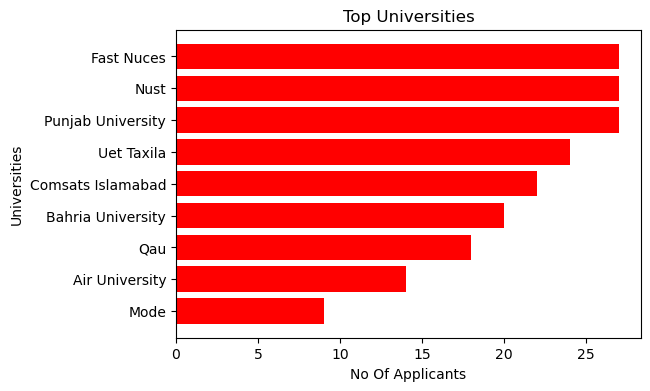

FAST NUCES, NUST, and Punjab University contributed the highest number of applications, making them the leading sources of applicants.


In [41]:
#Which Universities Sent the Most Applicants? 
Top_Uni=df['University'].value_counts()
print(Top_Uni)
plt.figure(figsize=(6,4))
plt.barh(Top_Uni.index,Top_Uni.values,color='red')
plt.gca().invert_yaxis()   # Largest bar appears at the top
plt.title('Top Universities')
plt.xlabel('No Of Applicants')
plt.ylabel('Universities')
plt.show()
print('FAST NUCES, NUST, and Punjab University contributed the highest number of applications, making them the leading sources of applicants.')

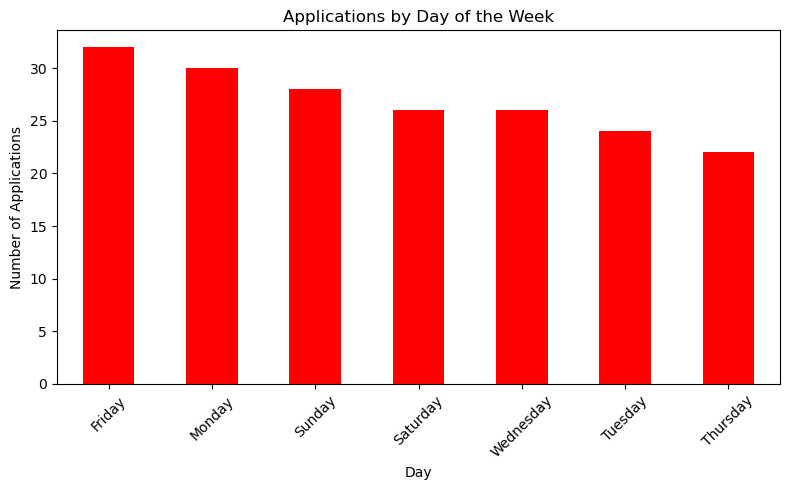

The highest number of applications were submitted on Friday, whereas Thursday recorded the fewest submissions.


In [42]:
#Applicants by day of week
df['Day'] = df['Application Date'].dt.day_name()
day_counts = df['Day'].value_counts()
plt.figure(figsize=(8,5))
day_counts.plot(kind='bar', color='red')
plt.title('Applications by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print('The highest number of applications were submitted on Friday, whereas Thursday recorded the fewest submissions.')